### **Linear SVM-based classification with word embeddings**

This notebook implements a text classification pipeline using dense vector representations derived from static word embeddings (ItaliaNLP Lab). Document embeddings are generated by aggregating token vectors, testing different pooling strategies (Mean, Sum, Max) and Part-Of-Speech (POS) filters (Semantic, Structural, and All words). Out-of-vocabulary tokens are managed through a robust normalization fallback chain. 

Model selection is conducted by evaluating configurations on the Validation set per project guidelines, followed by hyperparameter tuning via `GridSearchCV` (5-fold CV on the Training set). Finally, the optimal model is assessed on the Validation and Test sets using comprehensive visual diagnostics and generalization checks.

In [10]:
import os
import ast
import re
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import hinge_loss, f1_score
from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import display


### Data Loading and Embeddings Extraction
This cell defines a utility function to connect to the SQLite database containing the static word embeddings (ItaliaNLP Lab's `itwac128`) and load them into a memory-efficient Python dictionary. The function dynamically constructs the SQL query to retrieve the 128-dimensional vectors stored across separate columns (`dim0` to `dim127`), reconstructing them into standard NumPy arrays for fast vector operations during document representation.

In [11]:
def load_sqlite_embeddings(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Dynamically build the SELECT query for 'key' and 'dim0' through 'dim127'
    dim_cols = [f"dim{i}" for i in range(128)]
    query = f"SELECT key, {', '.join(dim_cols)} FROM store"
    
    cursor.execute(query)
    embeddings = {}
    
    # Fetch all rows and reconstruct the numpy arrays
    for row in cursor.fetchall():
        word = row[0]
        # row[1:129] contains the 128 float values
        vector = np.array(row[1:129], dtype=np.float32) 
        embeddings[word] = vector
        
    conn.close()
    print(f"Loaded {len(embeddings)} word embeddings.")
    return embeddings

# Load the embeddings from the specific database
embeddings_db_path = "../data/embeddings/itwac128.sqlite" 
word_embeddings = load_sqlite_embeddings(embeddings_db_path)

Loaded 1247492 word embeddings.


### Building Document Representations
This cell implements the core logic for transforming raw texts into dense document-level vectors. First, helper functions are defined to safely parse token and Part-Of-Speech lists (`_maybe_parse_list`) and to retrieve individual word vectors using a fallback normalization chain (`normalize_and_get_vector`) that handles casing, numbers, URLs, and long tokens. 

Next, the `get_doc_embedding` function aggregates these vectors using user-defined strategies (`mean`, `sum`, or `max`) while optionally filtering tokens based on their syntactic category (`pos_filters`). Finally, `create_feature_matrix` applies this transformation across entire datasets, ensuring dynamic and robust identification of the appropriate text and POS columns.

In [12]:
# Load dataframes and target vectors
print("Loading dataframes...")
df_train = pd.read_pickle("../data/enriched/train_final.pkl")
df_val = pd.read_pickle("../data/enriched/val_final.pkl")
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

y_train = df_train['label'].copy()
y_val = df_val['label'].copy()
y_test = df_test['label'].copy()

# Max length for literal parsing to prevent memory issues with plain text
_MAX_LITERAL_LEN = 5000

# Safely parses string representation of lists, falling back to split()
def _maybe_parse_list(s):
    s_stripped = s.strip()
    if s_stripped.startswith('[') and s_stripped.endswith(']') and len(s_stripped) <= _MAX_LITERAL_LEN:
        try:
            parsed = ast.literal_eval(s_stripped)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
    return s.split()

# Looks up token embedding with a fallback normalization chain
def normalize_and_get_vector(word, embeddings_dict):
    if word in embeddings_dict:
        return embeddings_dict[word]
    
    word_lower = word.lower()
    if word_lower in embeddings_dict:
        return embeddings_dict[word_lower]
        
    word_cap = word.capitalize()
    if word_cap in embeddings_dict:
        return embeddings_dict[word_cap]

    if re.match(r'(https?://|www\.)\S+', word):
        return embeddings_dict.get("___URL___")
        
    if len(word) > 26:
        return embeddings_dict.get("__LONG-LONG__")
        
    if any(ch.isdigit() for ch in word):
        return embeddings_dict.get("@Dg")

    return None

# Converts a document into a dense vector via embedding aggregation
def get_doc_embedding(tokens, pos_tags, embeddings_dict, pos_filters=None, agg_method='mean'):
    if isinstance(tokens, str):
        tokens = _maybe_parse_list(tokens)
    if isinstance(pos_tags, str):
        pos_tags = _maybe_parse_list(pos_tags)

    vecs = []
    for t, p in zip(tokens, pos_tags):
        if pos_filters is not None and p not in pos_filters:
            continue
        vec = normalize_and_get_vector(t, embeddings_dict)
        if vec is not None:
            vecs.append(vec)

    if len(vecs) == 0:
        dim = len(next(iter(embeddings_dict.values()))) if embeddings_dict else 128
        return np.zeros(dim, dtype=np.float32)

    stacked = np.vstack(vecs)
    if agg_method == 'mean':
        return np.mean(stacked, axis=0)
    elif agg_method == 'sum':
        return np.sum(stacked, axis=0)
    elif agg_method == 'max':
        return np.max(stacked, axis=0)
    else:
        raise ValueError("Unsupported aggregation method. Use 'mean', 'sum' or 'max'.")


def create_feature_matrix(df, embeddings_dict, pos_filters, agg_method):
    """Applies document embedding strategy to the entire DataFrame."""
    tok_col = 'tokens_processed' if 'tokens_processed' in df.columns else 'tokens'
    pos_col = 'pos_processed' if 'pos_processed' in df.columns else 'pos'

    if tok_col not in df.columns and 'lemmas_processed' in df.columns:
        tok_col = 'lemmas_processed'

    features = df.apply(
        lambda row: get_doc_embedding(row[tok_col], row[pos_col], embeddings_dict, pos_filters, agg_method),
        axis=1
    )
    return np.vstack(features.values)

Loading dataframes...


### Model selection via Validation Set
In this phase, different textual representations are evaluated by systematically combining various Part-Of-Speech filters (`All`, `Semantic`, and `Structural` words) with distinct embedding aggregation strategies (`mean`, `sum`, and `max` pooling). For each of the 9 configurations, dense feature matrices are computed for both the training and validation sets. A `Pipeline` incorporating a `StandardScaler` and a `LinearSVC` is then trained on the training data and evaluated directly on the validation set using the Macro-F1 score. Finally, the results are compiled into a sorted leaderboard to identify and isolate the optimal configuration for subsequent tuning.

In [13]:
# Define the experimental configurations: 3 pooling strategies x 3 POS filters
pos_configs = {
    "All": None,
    "Semantic": ['NOUN', 'VERB', 'ADJ', 'ADV'],
    "Structural": ['PRON', 'ADP', 'CCONJ', 'SCONJ', 'DET', 'AUX'],
}
pooling_strategies = ['mean', 'sum', 'max']

configs = {
    f"{pos_name}_{pool}": {"pos": pos_filter, "agg": pool}
    for pool in pooling_strategies
    for pos_name, pos_filter in pos_configs.items()
}

val_results = []
best_score = 0
best_config_name = None
best_params = None

print("--- Starting Validation Phase ---")

for config_name, params in configs.items():
    print(f"Testing Configuration: {config_name}")

    # 1. Create dense feature matrices
    X_train_dense = create_feature_matrix(df_train, word_embeddings, params["pos"], params["agg"])
    X_val_dense = create_feature_matrix(df_val, word_embeddings, params["pos"], params["agg"])

    # 2. Build the pipeline (Scaling is highly recommended for dense embeddings)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, random_state=42, dual=False, max_iter=5000))
    ])

    # 3. Fit on Training set
    pipeline.fit(X_train_dense, y_train)

    # 4. Predict and evaluate on Validation set
    pred_val = pipeline.predict(X_val_dense)
    mean_score = f1_score(y_val, pred_val, average="macro")

    print(f"Validation Macro-F1: {mean_score:.4f}\n")
    val_results.append({"Configuration": config_name, "Macro F1 (Val)": mean_score})

    # Track the best configuration
    if mean_score > best_score:
        best_score = mean_score
        best_config_name = config_name
        best_params = params

# Leaderboard, sorted by Macro F1
val_results_df = pd.DataFrame(val_results).sort_values(by="Macro F1 (Val)", ascending=False).reset_index(drop=True)
print("\n--- VALIDATION LEADERBOARD ---")
display(val_results_df)

print(f"\n*** Best Configuration Found: {best_config_name} (Val Macro-F1: {best_score:.4f}) ***\n")


--- Starting Validation Phase ---
Testing Configuration: All_mean
Validation Macro-F1: 0.9485

Testing Configuration: Semantic_mean
Validation Macro-F1: 0.9100

Testing Configuration: Structural_mean
Validation Macro-F1: 0.9095

Testing Configuration: All_sum
Validation Macro-F1: 0.9615

Testing Configuration: Semantic_sum
Validation Macro-F1: 0.9299

Testing Configuration: Structural_sum
Validation Macro-F1: 0.9280

Testing Configuration: All_max
Validation Macro-F1: 0.8980

Testing Configuration: Semantic_max
Validation Macro-F1: 0.8655

Testing Configuration: Structural_max
Validation Macro-F1: 0.8084


--- VALIDATION LEADERBOARD ---


,Configuration,Macro F1 (Val)
0,All_sum,0.961493
1,All_mean,0.948499
2,Semantic_sum,0.929928
3,Structural_sum,0.927977
4,Semantic_mean,0.909982
5,Structural_mean,0.909496
6,All_max,0.898000
7,Semantic_max,0.865496
8,Structural_max,0.808448



*** Best Configuration Found: All_sum (Val Macro-F1: 0.9615) ***



### Hyperparameter Tuning of the Winning Configuration
Once the optimal textual representation is identified via validation, dense feature matrices for the train, validation, and test sets are reconstructed specifically for this winning configuration. A `GridSearchCV` with a 5-fold cross-validation is then conducted strictly on the training set to fine-tune the classifier's hyperparameters. The grid explores different combinations of regularization strengths (`C`), penalties (`l1` or `l2`), and loss functions (`hinge` or `squared_hinge`), ensuring valid solver configurations (`dual`). The best-performing estimator is thus selected as the final pipeline.

In [14]:
# Rebuild the feature matrices for the winning configuration only
print(f"Rebuilding features with best configuration: {best_config_name} -> {best_params}")

X_train_best = create_feature_matrix(df_train, word_embeddings, best_params["pos"], best_params["agg"])
X_val_best   = create_feature_matrix(df_val,   word_embeddings, best_params["pos"], best_params["agg"])
X_test_best  = create_feature_matrix(df_test,  word_embeddings, best_params["pos"], best_params["agg"])

pipeline_tune = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(random_state=42, max_iter=20000))
])

# Each dict pairs penalty/loss with the only valid `dual` setting, to avoid both invalid combinations and unnecessary ConvergenceWarnings.
param_grid = [
    {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l2"], "clf__loss": ["hinge"], "clf__dual": [True]},
    {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l2"], "clf__loss": ["squared_hinge"], "clf__dual": [False]},
    {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l1"], "clf__loss": ["squared_hinge"], "clf__dual": [False]},
]

grid_search = GridSearchCV(
    pipeline_tune,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_best, y_train)

print(f"\nBest hyperparameters: {grid_search.best_params_}")
print(f"Best CV Macro-F1 (Training set, 5-fold): {grid_search.best_score_:.4f}")

final_pipeline = grid_search.best_estimator_


Rebuilding features with best configuration: All_sum -> {'pos': None, 'agg': 'sum'}
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best hyperparameters: {'clf__C': 1, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Best CV Macro-F1 (Training set, 5-fold): 0.9652


### Final Evaluation on Validation and Test Sets

Using the tuned pipeline from the grid search above (already fit on the Training set), we predict on the Validation and Test sets and report the full classification metrics for both.

In [15]:
# Predicted labels on each split, using the tuned pipeline
pred_train = final_pipeline.predict(X_train_best)
pred_val   = final_pipeline.predict(X_val_best)
pred_test  = final_pipeline.predict(X_test_best)

# Decision function scores (LinearSVC has no predict_proba -> needed for ROC/PR curves and hinge loss)
scores_train = final_pipeline.decision_function(X_train_best)
scores_val   = final_pipeline.decision_function(X_val_best)
scores_test  = final_pipeline.decision_function(X_test_best)

classes = sorted(y_train.unique())
n_classes = len(classes)

print("=== Classification Report - Validation Set ===")
print(classification_report(y_val, pred_val, digits=4))

print("=== Classification Report - Test Set ===")
print(classification_report(y_test, pred_test, digits=4))


=== Classification Report - Validation Set ===
              precision    recall  f1-score   support

           0     0.9743    0.9480    0.9610      1000
           1     0.9494    0.9750    0.9620      1000

    accuracy                         0.9615      2000
   macro avg     0.9618    0.9615    0.9615      2000
weighted avg     0.9618    0.9615    0.9615      2000

=== Classification Report - Test Set ===
              precision    recall  f1-score   support

           0     0.8894    0.9330    0.9107      1000
           1     0.9295    0.8840    0.9062      1000

    accuracy                         0.9085      2000
   macro avg     0.9095    0.9085    0.9084      2000
weighted avg     0.9095    0.9085    0.9084      2000



### Visual Diagnostics

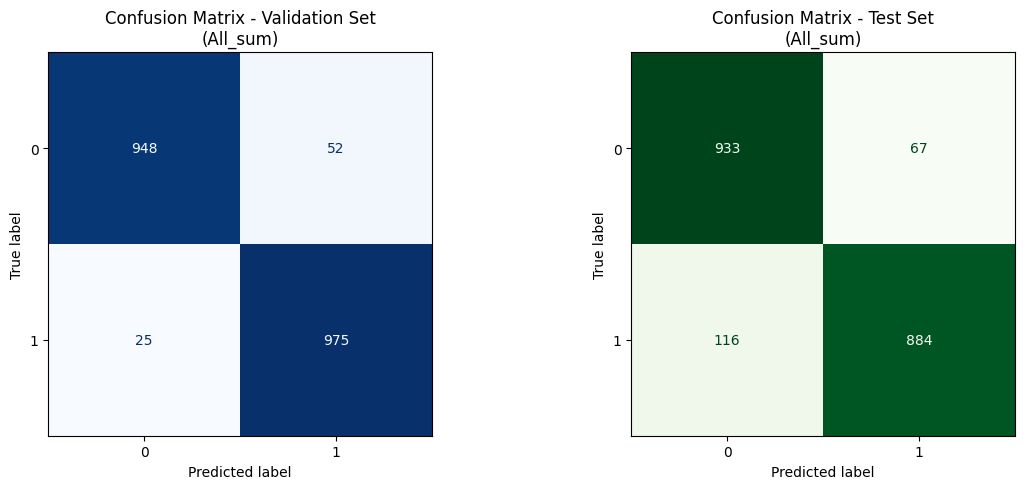

In [16]:
# Confusion matrices: Validation vs Test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix - Validation Set\n({best_config_name})")

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Confusion Matrix - Test Set\n({best_config_name})")

plt.tight_layout()
plt.show()


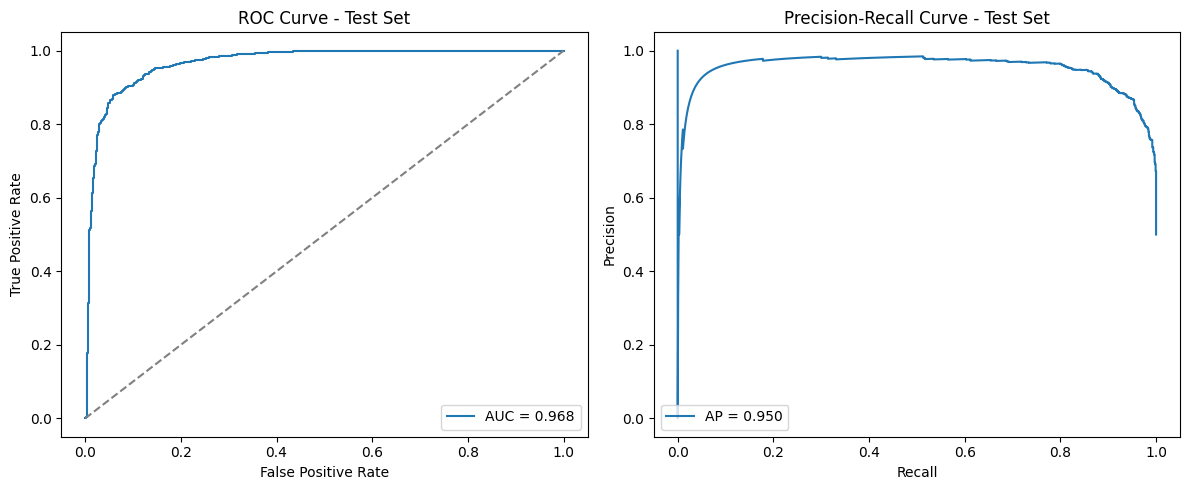

In [17]:
# ROC & PR Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, scores_test)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve - Test Set")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_test, scores_test)
    ap = average_precision_score(y_test, scores_test)
    axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve - Test Set")
    axes[1].legend(loc="lower left")
else:
    y_test_bin = label_binarize(y_test, classes=classes)
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], scores_test[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f"Class {c} (AUC={roc_auc:.3f})")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve (One-vs-Rest) - Test Set")
    axes[0].legend(loc="lower right", fontsize=8)

    for i, c in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], scores_test[:, i])
        ap = average_precision_score(y_test_bin[:, i], scores_test[:, i])
        axes[1].plot(recall, precision, label=f"Class {c} (AP={ap:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve (One-vs-Rest) - Test Set")
    axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()


### Overfitting Diagnostics
To evaluate the model's generalization capabilities, we compare the Macro-F1 score and Hinge Loss across the Training, Validation, and Test sets. A side-by-side bar chart visualizes performance consistency across splits, complemented by a generalization gap metric to detect potential overfitting.

Macro-F1  -> Train: 0.9785 | Val: 0.9615 | Test: 0.9084
HingeLoss -> Train: 0.0735 | Val: 0.1105 | Test: 0.3820


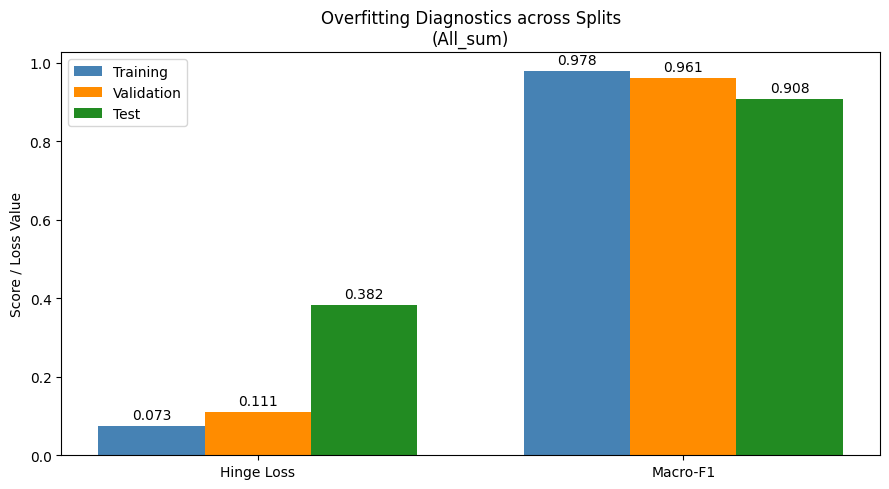


Generalization gap (Train - Test Macro-F1): 0.0701
=> The gap is limited: the model generalizes reasonably well to unseen data.


In [18]:
# Overfitting analysis: Macro-F1 and Hinge Loss across Train / Validation / Test
def compute_hinge(y_true, scores):
    return hinge_loss(y_true, scores) if n_classes == 2 else hinge_loss(y_true, scores, labels=classes)

f1_train = f1_score(y_train, pred_train, average="macro")
f1_val   = f1_score(y_val,   pred_val,   average="macro")
f1_test  = f1_score(y_test,  pred_test,  average="macro")

hinge_train = compute_hinge(y_train, scores_train)
hinge_val   = compute_hinge(y_val,   scores_val)
hinge_test  = compute_hinge(y_test,  scores_test)

print(f"Macro-F1  -> Train: {f1_train:.4f} | Val: {f1_val:.4f} | Test: {f1_test:.4f}")
print(f"HingeLoss -> Train: {hinge_train:.4f} | Val: {hinge_val:.4f} | Test: {hinge_test:.4f}")

# Graphical Visualization (Comparative Grouped Bar Chart)
metrics = ['Hinge Loss', 'Macro-F1']
train_scores = [hinge_train, f1_train]
val_scores = [hinge_val, f1_val]
test_scores = [hinge_test, f1_test]

x = np.arange(len(metrics)) 
width = 0.25  

fig, ax = plt.subplots(figsize=(9, 5))

# Plotting the grouped bars
rects1 = ax.bar(x - width, train_scores, width, label='Training', color='steelblue')
rects2 = ax.bar(x, val_scores, width, label='Validation', color='darkorange')
rects3 = ax.bar(x + width, test_scores, width, label='Test', color='forestgreen')

# Formatting the plot
ax.set_ylabel('Score / Loss Value')
ax.set_title(f'Overfitting Diagnostics across Splits\n({best_config_name})')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Adding value labels on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')
ax.bar_label(rects3, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

# Generalization Gap
gap = f1_train - f1_test
print(f"\nGeneralization gap (Train - Test Macro-F1): {gap:.4f}")
if gap > 0.10:
    print("=> Significant gap detected: the model may be overfitting the training data.")
else:
    print("=> The gap is limited: the model generalizes reasonably well to unseen data.")